# Paper figures — 3 floats, 4 RQs

**This notebook is the one entry point from raw logs to paper numbers**: the first
cell rebuilds every `tables/*.csv` from the run logs in `logs/` (via
`scripts/gap_tables.py`, the single source of truth for the selection rules), and
the cells below build the Results figures from those tables. A fresh clone with the
`logs/` tree runs top to bottom with no other inputs.

File names keep their historical numbers (`fig2_recovery` …) — LaTeX renumbers the
floats itself:

1. **fig2_recovery (RQ2)** — recovery forest: each method's real gap vs direct transfer on the same cells.
2. **fig3_networks (RQ1 + RQ3)** — per-family Direct-Transfer distributions on top of the
   network × perturbation split-triangle heatmap (DT vs best-known method).
3. **fig4_controllers (RQ4)** — DQN vs PressLight agreement scatter (post-mitigation, both panels).

`fig1_anatomy` (per-source anatomy boxes) was dropped 2026-07-26; the distribution row of
fig3 carries that content at setting-family resolution.

Conventions: ATT gaps in ABSOLUTE seconds (real ATT − CF baseline); reward chapter uses
**regret** vs the known-w* oracle (regret_π := R_oracle − R_π; regret_DT = the sim2real-gap
proxy, since R_real is not computable in sim); fixed axis colors (Okabe-Ito).
Panel subtitles sit at the BOTTOM of each panel in the paper's serif face
(`SUBTITLE_FONT`); reading rules/hints are legend material, never a suptitle;
crowded x ticks rotate 45°.

**Naming.** Canonical names live in `GLOSSARY.md` (repo root). Every tick, legend entry and axis label goes through the display-name maps in
the setup cell (`NETWORK_LABELS`, `METHOD_LABELS`, `SETTING_LABELS`). Raw CSV identifiers
(`oblivious_q`, `tempe_1x1`, `setting1`, …) must never reach the page; they appear in the
paper only in the "Identifier in results tables" column of `tables/method_glossary.tex`.
The setup cell asserts that every identifier in the data has a display name.

**Sizing.** Figures are authored at their final printed width (`FULL_W` = 7.0in for a
`figure*`, `COL_W` = 3.3125in for one column) so LaTeX never rescales them and a 7pt label
prints at 7pt.

Output: `Figures/*.pdf` (vector, PDF only — the paper embeds these directly).

In [1]:
# Rebuild every tables/*.csv from the raw run logs (logs/ -> tables/ -> Figures/):
# the notebook is self-contained given the logs tree. Selection rules and CSV
# schemas live in scripts/gap_tables.py; the analyze_*.ipynb notebooks share them.
from scripts.gap_tables import build_all

build_all()
print('tables rebuilt from logs/')

wrote 20 rows to tables/engine_baseline_table.csv
wrote 2240 rows to tables/observation_table.csv
wrote 440 rows to tables/transition_table.csv
wrote 400 rows to tables/action_table.csv
wrote 280 rows to tables/action_pt_table.csv
wrote 400 rows to tables/reward_table.csv
16 tables -> tables/reward_gap/
tables rebuilt from logs/


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLES = Path('tables')
FIG_DIR = Path('Figures')  # matches \includegraphics{Figures/...} (Overleaf is case-sensitive)
FIG_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------ print size
# AAAI 2027: \textwidth = 7.0in, \columnsep = 0.375in -> \columnwidth = 3.3125in.
# Author every figure at its FINAL printed width so LaTeX never rescales it and a
# 7pt label prints at 7pt. A figure authored wider is shrunk by the width ratio,
# and its type shrinks with it -- the cause of every "font too small" complaint.
FULL_W = 7.0      # figure* (spans both columns)
COL_W = 3.3125    # figure (one column)

plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 8.5,
    'axes.labelsize': 8,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'pdf.fonttype': 42,  # embed TrueType rather than Type 3
    'ps.fonttype': 42,
})

# ---------------------------------------------------------- figure conventions
# (2026-07-26) Panel subtitles ("(a) ATT gap") sit at the BOTTOM of each panel,
# set in the serif face the paper body uses (Times New Roman; newtxtext in the
# LaTeX). Reading rules and hints are legend material -- placed with or below
# the legend, never as a suptitle. X ticks that would collide rotate 45 deg.
SUBTITLE_FONT = {'fontfamily': 'Times New Roman', 'fontsize': 9}

# ------------------------------------------------------------------- gap axes
# Canonical order is the MDP tuple order S, A, T, R (decision 2026-07-26):
# observation, both action sub-gaps, transition, then reward. GLOSSARY.md and
# fig0 use the same order -- change all three together.
GAP_AXES = ['observation', 'action_delay', 'action_pt', 'transition']
AXIS_LABELS = {'observation': 'Observation', 'transition': 'Transition',
               'action_delay': 'Action (delay)',
               'action_pt': 'Action (phase transitions)',
               'reward': 'Reward'}
# wrapped forms for tick labels and group headers, where horizontal room is scarce
AXIS_TICKS = {'observation': 'Observation', 'transition': 'Transition',
              'action_delay': 'Action\n(delay)',
              'action_pt': 'Action\n(phase transitions)', 'reward': 'Reward'}
# three-line forms for the fig-3 group headers, where a span is only 4-5 columns wide
AXIS_HDR = {'observation': 'Observation', 'transition': 'Transition',
            'action_delay': 'Action\n(delay)',
            'action_pt': 'Action\n(phase\ntransitions)', 'reward': 'Reward'}
# Okabe-Ito (CVD-safe, high contrast on white; replaced Tol bright -- its yellow washed
# out). action_pt is Okabe-Ito orange darkened from #E69F00: at the true printed size
# the semi-transparent dots in that yellow were unreadable on white. Same hue, so it
# stays distinct from the vermillion used for transition.
AXIS_COLORS = {'observation': '#0072B2', 'transition': '#D55E00',
               'action_delay': '#009E73', 'action_pt': '#B07C00', 'reward': '#AA3377'}
# Darker twins for TEXT. The marker fills above are tuned for filled shapes; as thin
# 7pt type on white the orange especially drops below a readable contrast ratio.
AXIS_TEXT_COLORS = {'observation': '#005E93', 'transition': '#A84800',
                    'action_delay': '#00785A', 'action_pt': '#8A6100',
                    'reward': '#8A2A5E'}

# --------------------------------------------------------- display names
# Single source of truth for every tick, legend entry and axis label below. The
# raw CSV identifiers are internal; in the paper they survive only in the
# "Identifier in results tables" column of tables/method_glossary.tex.
NETWORK_LABELS = {
    'tempe_1x1': 'Tempe 1×1', 'tempe_16': 'Tempe 16',
    'bullhead_1': 'Bullhead 1', 'bullhead_3': 'Bullhead 3',
    'cologne1': 'Cologne 1', 'cologne3': 'Cologne 3',
    'ingolstadt1': 'Ingolstadt 1', 'ingolstadt7': 'Ingolstadt 7',
    'hz1x1': 'Hangzhou 1×1', 'hz4x4': 'Hangzhou 4×4',
}

METHOD_LABELS = {
    'direct_transfer': 'Direct-Transfer',
    # observation
    'domain_randomization': 'Domain Randomization',
    'lusr': 'LUSR', 'darla': 'DARLA', 'atc': 'ATC', 'vae': 'VAE',
    'recon_baseline': 'Reconstruction',
    # transition
    'domain_adaptation': 'Domain Adaptation',
    'gat': 'GAT', 'ugat': 'UGAT', 'jlgat': 'JL-GAT',
    # action (delay)
    'naive': 'Ignore-Delay', 'oblivious_q': 'Oblivious-Q',
    'delayed_q': 'Delayed-Q', 'prlight': 'PRLight',
    # action (phase transitions). Per tables/method_glossary.tex `dr` IS the
    # shielded run and `dr_noshield` its unshielded twin: the identifier reads
    # the opposite way round, so it must never reach the page unlabelled.
    'dr': 'Domain Rand. + Shield',
    'dr_noshield': 'Domain Randomization',
    'gat_shield': 'GAT + Shield', 'ugat_shield': 'UGAT + Shield',
    # reward
    'reward_inference': 'Reward Inference', 'morl_grid': 'Multi-objective RL',
    'dynamic_reward_shaping': 'Dynamic Reward Shaping',
    'reward_oracle': 'Reward Oracle',
}

# Short forms for FIGURE TICKS, as introduced by fig0 and re-introduced in the
# Benchmark Design prose (see GLOSSARY.md); methods already short keep their
# METHOD_LABELS name. In the phase-transition group `dr_noshield` -> DR and
# `dr` -> DR+Shield, matching the glossary's warning about the identifiers.
METHOD_ABBREV = {
    'direct_transfer': 'DT', 'domain_randomization': 'DR',
    'recon_baseline': 'Recon', 'domain_adaptation': 'DA',
    'reward_inference': 'RI', 'morl_grid': 'MORL',
    'dynamic_reward_shaping': 'DRS', 'dr': 'DR+Shield',
    'gat_shield': 'GAT+Shield', 'ugat_shield': 'UGAT+Shield',
    'dr_noshield': 'DR',
}


def method_abbrev(m):
    return METHOD_ABBREV.get(m, METHOD_LABELS.get(m, m))


# Settings are keyed BY AXIS: setting1..setting4 mean different things under
# transition (road condition) and under action delay (seconds), so one flat map
# would print one axis's meaning on the other's ticks.
SETTING_LABELS = {
    'observation': {
        'noise3': '$\\sigma$=3', 'noise5': '$\\sigma$=5',
        'noise10': '$\\sigma$=10', 'noise20': '$\\sigma$=20',
        'dz100': '100 m', 'dz50': '50 m', 'dz20': '20 m', 'dz10': '10 m',
        'sensor5': '5%', 'sensor20': '20%', 'sensor50': '50%', 'sensor70': '70%',
        'combine1': 'C1', 'combine2': 'C2', 'combine3': 'C3', 'combine4': 'C4',
    },
    # tables/transition_settings.tex, in column order after Nominal
    'transition': {'setting1': 'Light load', 'setting2': 'Heavy load',
                   'setting3': 'Rain', 'setting4': 'Snow'},
    # verified against the action_delay column of tables/action_table.csv
    'action_delay': {'setting1': '20 s', 'setting2': '30 s',
                     'setting3': '40 s', 'setting4': '60 s'},
    'action_pt': {'flexible': 'Flexible', 'cyclic': 'Cyclic',
                  'barrier_leading_fixed': 'Barrier (lead)',
                  'barrier_lagging_fixed': 'Barrier (lag)',
                  'barrier_leading_lagging_fixed': 'Barrier (lead+lag)'},
    'reward': {'efficiency_aligned': 'Efficiency', 'emission_heavy': 'Emission',
               'fairness_heavy': 'Fairness', 'physical_safety_heavy': 'Safety'},
}

# Sub-groups within a gap source, for the fig-3 family header row. Observation and
# transition each mix distinct kinds of perturbation, so the family name says what
# a column varies; the action and reward sources vary one thing and need no row.
# Observation families run mild -> severe. Note the detection zone runs 100 -> 10 m:
# a SHORTER zone sees less, so it is the severe end.
SETTING_FAMILIES = {
    'observation': [('Noise $\\sigma$', ['noise3', 'noise5', 'noise10', 'noise20']),
                    ('Detection\nzone', ['dz100', 'dz50', 'dz20', 'dz10']),
                    ('Sensor\nfailure', ['sensor5', 'sensor20', 'sensor50', 'sensor70']),
                    ('Combined', ['combine1', 'combine2', 'combine3', 'combine4'])],
    # Two columns each, so ~0.25in of room per label. A second line ("Vehicle" over
    # "load") puts the lower word right beside "Weather" and the two groups stop
    # reading as separate, so both stay one short word. The tick labels underneath
    # ("Light load", "Heavy load") carry the vehicle sense.
    'transition': [('Load', ['setting1', 'setting2']),
                   ('Weather', ['setting3', 'setting4'])],
}

# per-axis column order used by the fig-3 grid
SETTING_ORDER = {
    'action_delay': [f'setting{i}' for i in range(1, 5)],
    'action_pt': ['flexible', 'barrier_leading_fixed', 'barrier_lagging_fixed',
                  'barrier_leading_lagging_fixed', 'cyclic'],
    'reward': ['efficiency_aligned', 'emission_heavy', 'fairness_heavy',
               'physical_safety_heavy'],
}
# where an axis has families, the family order IS the column order -- one source
# of truth, so a column can never drift out of the family that heads it
for _ax, _fams in SETTING_FAMILIES.items():
    SETTING_ORDER[_ax] = [s for _, ss in _fams for s in ss]


def net_label(n):
    return NETWORK_LABELS.get(n, n)


def method_label(m):
    return METHOD_LABELS.get(m, m)


def setting_label(axis, s):
    return SETTING_LABELS.get(axis, {}).get(s, s)


def load_gap_table(name, axis):
    df = pd.read_csv(TABLES / name)
    df['axis'] = axis
    df['tt_mean'] = df['travel_time'].astype(str).str.split(' ').str[0].astype(float)
    df['gap'] = df['gap_vs_cityflow'].astype(float)
    df['cf_att'] = df['cityflow_att'].astype(float)
    df['rel_gap'] = df['gap'] / df['cf_att']
    return df


gaps = pd.concat([
    load_gap_table('observation_table.csv', 'observation'),
    load_gap_table('transition_table.csv', 'transition'),
    load_gap_table('action_table.csv', 'action_delay'),
    load_gap_table('action_pt_table.csv', 'action_pt'),
], ignore_index=True)

rewards = pd.read_csv(TABLES / 'reward_table.csv')
# reward_oracle is the REFERENCE, not a method row (decision 2026-07-22): the reward
# chapter's gap proxy is recoverable R_real := R_oracle - R_pi -- the distance to the
# known-w* skyline, the only cross-policy currency R_real admits. Split it off so the
# method rows / best-of below range over the budgeted roster only.
r_oracle = (rewards[rewards.method == 'reward_oracle']
            .set_index(['agent', 'network', 'setting'])['R_real'])
rewards = rewards[rewards.method != 'reward_oracle'].copy()

engine = pd.read_csv(TABLES / 'engine_baseline_table.csv')
engine['rel_floor'] = engine['engine_gap'] / engine['cityflow_att']

dt = gaps[gaps.method == 'direct_transfer'].copy()

# every identifier that reaches a tick must have a display name -- fail loudly here
# rather than silently printing `oblivious_q` in the paper
_missing = ({m for m in gaps.method.unique()} | {m for m in rewards.method.unique()}
            | {'reward_oracle'}) - set(METHOD_LABELS)
assert not _missing, f'unlabelled methods: {_missing}'
_missing = set(gaps.network.unique()) - set(NETWORK_LABELS)
assert not _missing, f'unlabelled networks: {_missing}'
for _ax in GAP_AXES:
    _missing = set(gaps[gaps.axis == _ax].setting.unique()) - set(SETTING_LABELS[_ax])
    assert not _missing, f'unlabelled {_ax} settings: {_missing}'

print(f'{len(gaps)} gap rows ({len(dt)} direct-transfer cells), '
      f'{len(rewards)} reward rows + {len(r_oracle)} oracle reference cells, '
      f'{len(engine)} engine baselines')


def save(fig, name, target_w=FULL_W):
    # PDF only: the paper embeds vector figures, and the PNG twins just went stale.
    #
    # bbox_inches='tight' can EXPAND past figsize -- a left-aligned title or a long
    # tick label that overhangs the canvas is still inside the tight bbox. LaTeX then
    # rescales the file down to \textwidth and shrinks the type with it, which is the
    # bug this whole sizing policy exists to prevent. So iterate the figure size until
    # the TIGHT BOX is target_w, and \includegraphics[width=\textwidth] is a true 1.0x.
    out = FIG_DIR / f'{name}.pdf'
    bb = None
    for _ in range(5):
        fig.canvas.draw()
        bb = fig.get_tightbbox(fig.canvas.get_renderer())
        if abs(bb.width - target_w) < 0.02:
            break
        s = target_w / bb.width
        w, h = fig.get_size_inches()
        fig.set_size_inches(w * s, h * s)
    fig.savefig(out, bbox_inches='tight', pad_inches=0.01)
    print(f'saved {out}  ({bb.width:.2f} x {bb.height:.2f} in at 1.0x)')

3360 gap rows (520 direct-transfer cells), 320 reward rows + 80 oracle reference cells, 20 engine baselines


## Fig 2 — What mitigation recovers (RQ2), vertical

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

saved Figures/fig2_recovery.pdf  (6.99 x 2.79 in at 1.0x)


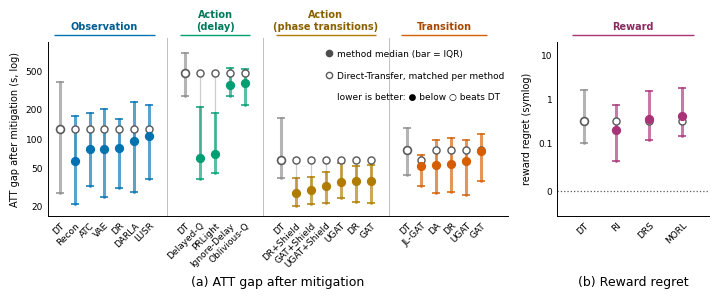

In [3]:
# Fig 2 - recovery forest (RQ2), VERTICAL (2026-07-27): methods are columns
# grouped by gap source, all four ATT sources in ONE left panel on ONE shared
# log scale (this replaces the old two-column split Hua questioned); reward on
# the right in its own currency, the same left/right split as fig3. Values in
# ABSOLUTE seconds: no recovery ratio -> no small-denominator filter; harm shows
# as the colored dot landing ABOVE its open DT marker.
# Column: colored bar = method's per-cell IQR; filled dot = median; open grey
# dot = DT median on the SAME cells; thin connector = the median shift. Each
# group leads with a grey DT column pooled over that gap's cells.
# Conventions: colored gap-source headers above the groups (fig3 grammar),
# x ticks are the fig0 short forms at 45 degrees, serif subtitles at the
# bottom, marker legend + reading hint top right.
dtg = dt.set_index(['axis', 'agent', 'network', 'setting'])['gap']
meth = gaps[gaps.method != 'direct_transfer'].copy()
meth['gap_dt'] = dtg.reindex(pd.MultiIndex.from_frame(meth[['axis', 'agent', 'network', 'setting']])).values

rows = []
for axis in GAP_AXES:
    sub = meth[meth.axis == axis]
    med = sub.groupby('method', observed=True)['gap'].median().sort_values()
    for m in med.index:
        r = sub[sub.method == m]
        rows.append({'axis': axis, 'method': m, 'n': len(r),
                     'med': r['gap'].median(), 'q1': r['gap'].quantile(0.25),
                     'q3': r['gap'].quantile(0.75), 'dt_med': r['gap_dt'].median()})
forest = pd.DataFrame(rows)

GROUP_GAP = 1.4  # blank columns between gap sources

# ------------------------------------------------------------------- geometry
n_att = sum(1 + (forest.axis == a).sum() for a in GAP_AXES)   # + a DT column each
n_rwd = rewards.method.nunique()                              # DT + 3 methods
L_M, R_M, WSP = 0.085, 0.995, 0.16
# 2026-07-27 (user, hand-placed in Adobe then encoded here): the marker legend
# moved OFF the foot and INTO panel (a)'s top-right headroom, stacked one entry
# per line. The foot now holds only the serif subtitles. ax.set_ylim's top
# headroom exists to hold this legend -- do not shrink it.
T_IN, B_IN = 0.44, 0.80        # header band / foot (inches)
SUB_IN = 0.22                  # subtitle anchor, inches from the figure bottom
# legend box corner in panel-(a) AXES fraction, upper-left of the box
LEG_XY = (0.592, 0.981)
PLOT_IN = 1.68                 # data area height
FIG_H = T_IN + PLOT_IN + B_IN
fig = plt.figure(figsize=(FULL_W, FIG_H))
# (b) gets more width than its 4 columns need: it hosts the legend, and the
# gutter is narrow so the two panels read as one figure
gs = fig.add_gridspec(1, 2, width_ratios=[n_att + 3 * GROUP_GAP, n_rwd * 2.4],
                      left=L_M, right=R_M, top=1 - T_IN / FIG_H,
                      bottom=B_IN / FIG_H, wspace=WSP)
ax = fig.add_subplot(gs[0, 0])
axr = fig.add_subplot(gs[0, 1])


def column(a, x, q1, q3, med, color, dt_med=None):
    """One vertical method column; dt_med=None draws the grey DT reference."""
    if dt_med is not None:
        a.plot([x, x], [med, dt_med], color='0.8', linewidth=0.9, zorder=1)
    a.plot([x, x], [q1, q3], color=color, linewidth=2.2, alpha=0.65,
           solid_capstyle='round', zorder=2)
    a.scatter([x, x], [q1, q3], marker='_', s=34, color=color, alpha=0.9,
              linewidths=1.2, zorder=2)
    if dt_med is not None:
        a.scatter([x], [dt_med], facecolors='white', edgecolors='0.35',
                  linewidths=1.0, s=26, zorder=3)
        a.scatter([x], [med], color=color, s=32, zorder=4)
    else:
        a.scatter([x], [med], facecolors='white', edgecolors='0.35',
                  linewidths=1.2, s=32, zorder=4)


# ---------------------------------------------------------- panel (a), ATT gap
xticks, xlabels, gspans = [], [], []
x = 0.0
for axis in GAP_AXES:
    start = x
    dsub = dt[dt.axis == axis]['gap']
    column(ax, x, dsub.quantile(0.25), dsub.quantile(0.75), dsub.median(), '0.55')
    xticks.append(x); xlabels.append(method_abbrev('direct_transfer'))
    x += 1
    for _, r in forest[forest.axis == axis].iterrows():
        column(ax, x, r.q1, r.q3, r.med, AXIS_COLORS[axis], dt_med=r.dt_med)
        xticks.append(x); xlabels.append(method_abbrev(r.method))
        x += 1
    gspans.append((start, x - 1, axis))
    x += GROUP_GAP

ax.set_yscale('log')
ax.set_yticks([20, 50, 100, 200, 500])
ax.set_yticklabels(['20', '50', '100', '200', '500'])
ax.minorticks_off()
ax.set_ylim(16, 1000)  # top headroom is the legend's space
ax.set_xlim(-0.8, x - GROUP_GAP + 0.8 - 1 + 1)
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, fontsize=6.5, rotation=45, ha='right',
                   rotation_mode='anchor')
ax.set_ylabel('ATT gap after mitigation (s, log)', fontsize=7)
ax.tick_params(axis='y', labelsize=6.5)
ax.tick_params(length=0)
ax.spines[['top', 'right']].set_visible(False)

# colored gap-source headers + separators, fig3 grammar; offsets are inches
# through PLOT_IN so they survive a height change
RULE_Y, HDR_Y = 1 + 0.06 / PLOT_IN, 1 + 0.10 / PLOT_IN
tr = ax.get_xaxis_transform()
for s_, e_, axis in gspans:
    ax.plot([s_ - 0.35, e_ + 0.35], [RULE_Y, RULE_Y], transform=tr,
            color=AXIS_COLORS[axis], linewidth=1.0, clip_on=False,
            solid_capstyle='butt')
    ax.text((s_ + e_) / 2, HDR_Y, AXIS_TICKS[axis], transform=tr, ha='center',
            va='bottom', fontsize=7, color=AXIS_TEXT_COLORS[axis],
            fontweight='bold', linespacing=1.2)
for (_, e_, _), (s2, _, _) in zip(gspans[:-1], gspans[1:]):
    xm = (e_ + s2) / 2
    ax.plot([xm, xm], [0, 1.02], transform=tr, color='0.75', linewidth=0.7,
            clip_on=False, zorder=1)

# ------------------------------------------------------- panel (b), reward
rw = rewards.copy()
rw['short'] = (r_oracle.reindex(pd.MultiIndex.from_frame(
    rw[['agent', 'network', 'setting']])).values - rw['R_real'])
dt_short = rw[rw.method == 'direct_transfer']['short']
column(axr, 0, dt_short.quantile(0.25), dt_short.quantile(0.75),
       dt_short.median(), '0.55')
rm = rw[rw.method != 'direct_transfer']
rmed = rm.groupby('method')['short'].median().sort_values()
rlabels = [method_abbrev('direct_transfer')]
for i, m in enumerate(rmed.index, start=1):
    r = rm[rm.method == m]['short']
    column(axr, i, r.quantile(0.25), r.quantile(0.75), r.median(),
           AXIS_COLORS['reward'], dt_med=dt_short.median())
    rlabels.append(method_abbrev(m))
axr.axhline(0, color='0.35', linewidth=0.9, linestyle=':', zorder=1)
axr.set_yscale('symlog', linthresh=0.1)
axr.set_yticks([0, 0.1, 1, 10])
axr.set_yticklabels(['0', '0.1', '1', '10'])
axr.minorticks_off()
axr.set_ylim(-0.05, 20)  # headroom keeps the zero line in the lower third
axr.set_xlim(-0.8, len(rmed) + 0.8)
axr.set_xticks(range(len(rmed) + 1))
axr.set_xticklabels(rlabels, fontsize=6.5, rotation=45, ha='right',
                    rotation_mode='anchor')
axr.set_ylabel('reward regret (symlog)', fontsize=7)
axr.tick_params(axis='y', labelsize=6.5)
axr.tick_params(length=0)
axr.spines[['top', 'right']].set_visible(False)
trr = axr.get_xaxis_transform()
axr.plot([-0.35, len(rmed) + 0.35], [RULE_Y, RULE_Y], transform=trr,
         color=AXIS_COLORS['reward'], linewidth=1.0, clip_on=False,
         solid_capstyle='butt')
axr.text(len(rmed) / 2, HDR_Y, AXIS_TICKS['reward'], transform=trr,
         ha='center', va='bottom', fontsize=7,
         color=AXIS_TEXT_COLORS['reward'], fontweight='bold')

# Each panel's serif subtitle sits at the foot; the legend lives inside panel
# (a) (see LEG_XY). The open circle is Direct-Transfer re-pooled over the cells
# each method actually covers, so it is matched per method rather than one
# global reference.
_pa, _pr = ax.get_position(), axr.get_position()
fig.text((_pa.x0 + _pa.x1) / 2, SUB_IN / FIG_H,
         '(a) ATT gap after mitigation', ha='center', va='top', **SUBTITLE_FONT)
fig.text((_pr.x0 + _pr.x1) / 2, SUB_IN / FIG_H, '(b) Reward regret',
         ha='center', va='top', **SUBTITLE_FONT)
handles = [plt.Line2D([], [], marker='o', color='0.3', linestyle='',
                      markersize=4.5, label='method median (bar = IQR)'),
           plt.Line2D([], [], marker='o', markerfacecolor='white',
                      markeredgecolor='0.35', linestyle='', markersize=4.5,
                      label='Direct-Transfer, matched per method'),
           plt.Line2D([], [], marker='', linestyle='',
                      label='lower is better: ● below ○ beats DT')]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=LEG_XY,
          bbox_transform=ax.transAxes, frameon=False, fontsize=6.5, ncol=1,
          handlelength=1.0, handletextpad=0.4, labelspacing=1.42, borderpad=0.0)

save(fig, 'fig2_recovery')
plt.show()


## Fig 3 — per-family distributions + where gaps live (RQ1 + RQ3)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

saved Figures/fig3_networks.pdf  (7.02 x 4.08 in at 1.0x)


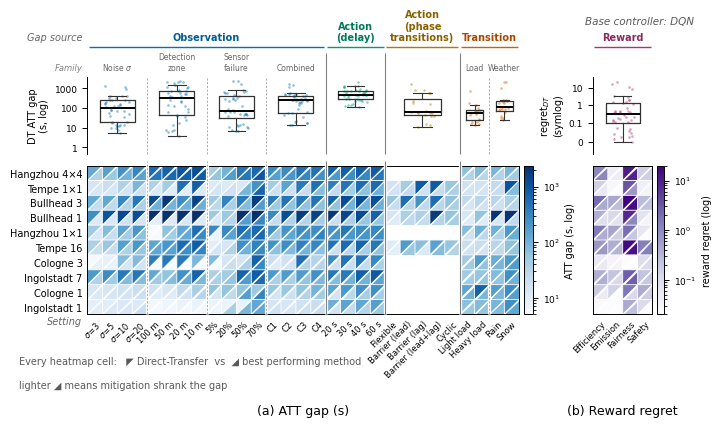

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

saved Figures/fig3_networks_presslight.pdf  (7.02 x 4.08 in at 1.0x)


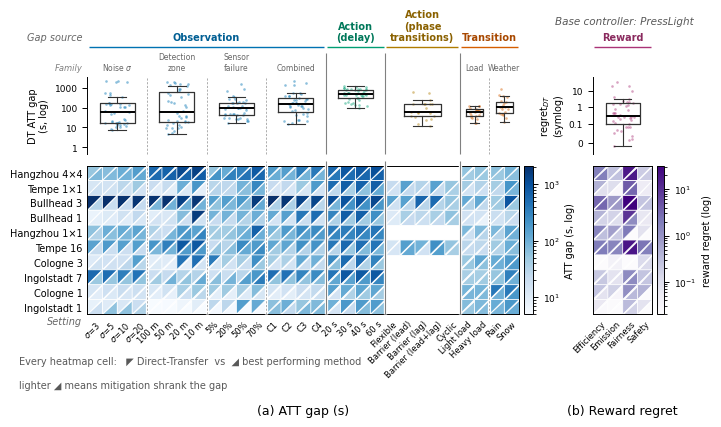

In [4]:
# Fig 3 - the gap by family and by network (RQ1 + RQ3), SQUARE heatmap cells,
# ONE FIGURE PER BASE CONTROLLER: DQN is the main-text figure, PressLight the
# appendix companion (decision 2026-07-27, replaces the median over the two
# controllers -- every cell is now one run's value directly). Both figures
# share net_order so rows line up across main text and appendix.
# TOP ROW (absorbs the old fig1 at finer resolution): per-family Direct-Transfer
# distributions -- each dot one deployment cell (controller x network x setting),
# box = median + IQR, whiskers 1.5x IQR. BOTTOM: split-cell heatmap, each cell =
# network x setting; UPPER-LEFT triangle = DT gap, LOWER-RIGHT = gap under
# the per-cell BEST-KNOWN method, SHARED Blues log scale so the triangles are
# directly comparable. Right block: reward in its own currency, SAME conventions,
# anchored to the ORACLE: top box = regret_DT distribution, heatmap upper-left =
# R_oracle - R_DT, lower-right = R_oracle - best budgeted method. Rows ordered by
# CF baseline ATT (saturation proxy). Columns carry their physical setting
# (SETTING_LABELS is keyed by axis: setting1..4 differs per axis). No pooling
# across axes anywhere.
# Conventions (2026-07-26/27): subtitles at the BOTTOM in the serif face; the
# split-cell reading rule is legend material at the foot, not a suptitle;
# x ticks at 45 degrees; heatmap cells are SQUARE, so the figure height is
# DERIVED from the fixed width rather than eyeballed.
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.cm import ScalarMappable

d3 = dt.copy()
d3['sev'] = d3['setting'].astype(str)

best = (gaps[gaps.method != 'direct_transfer']
        .groupby(['axis', 'agent', 'network', 'setting'], observed=True)['gap']
        .min().reset_index())
best['sev'] = best['setting'].astype(str)

# ALL settings listed -- no severity aggregation anywhere (cell median = over the
# 2 controllers only, uniformly). Obs ordered family by family, mild -> severe.
col_order = [(axis, s) for axis in GAP_AXES for s in SETTING_ORDER[axis]]
# where each gap source starts/ends in col_order, for the header rows and rules
spans, _c = [], 0
for axis in GAP_AXES:
    n = len(SETTING_ORDER[axis])
    spans.append((_c, _c + n, axis))
    _c += n

# Rows ordered by clean E_sim ATT, a saturation proxy. The ordering is a criterion
# only; the ATT value itself is not plotted, so the caption has to say what the order
# means.
net_order = list(dt.groupby('network')['cf_att'].median().sort_values(ascending=False).index)

# reward block: per cell, upper-left = R_oracle - R_DT; lower-right =
# NOTE R_real sums over intersections (global norms, no per-network calibration):
# color is comparable within a cell/row-pair, ordinal-only across networks --
# caption must not rank networks by raw shortfall (see analyze_rewards caveat 8).
# R_oracle - max over budgeted methods (>0 where even the best method trails the
# skyline; floored at 0.02 for the log scale, incl. the 3 cells where a method
# edged past the oracle by <=0.05).
r_dt = rewards[rewards.method == 'direct_transfer'].set_index(['agent', 'network', 'setting'])['R_real']
r_meth_best = rewards[rewards.method != 'direct_transfer'].groupby(['agent', 'network', 'setting'])['R_real'].max()
r_short = (r_oracle - r_dt).reset_index(name='short')
# label-aligned, NOT .values: (r_oracle - r_dt) keeps CSV row order while the
# groupby result is index-sorted -- positional assignment scrambles cells
r_short['short_best'] = (r_oracle - r_meth_best).reindex(
    pd.MultiIndex.from_frame(r_short[['agent', 'network', 'setting']])).values
RSET = SETTING_ORDER['reward']

AGENT_LABELS = {'dqn': 'DQN', 'presslight': 'PressLight'}


def draw_fig3(agent, out_name):
  # One base controller per figure: filter, then every (network, setting) is a
  # single run's value -- the groupby below is an index lookup, not pooling.
  dd = d3[d3.agent == agent]
  bb = best[best.agent == agent]
  rr = r_short[r_short.agent == agent]

  grid = np.full((len(net_order), len(col_order)), np.nan)
  grid_best = np.full_like(grid, np.nan)
  for j, (axis, sev) in enumerate(col_order):
      sub = dd[(dd.axis == axis) & (dd.sev == sev)]
      med = sub.groupby('network', observed=True)['gap'].median()
      bsub = bb[(bb.axis == axis) & (bb.sev == sev)]
      bmed = bsub.groupby('network', observed=True)['gap'].median()
      for i, net in enumerate(net_order):
          if net in med.index:
              grid[i, j] = max(med[net], 1.0)
          if net in bmed.index:
              grid_best[i, j] = max(bmed[net], 1.0)

  rgrid = np.full((len(net_order), len(RSET)), np.nan)
  rgrid_best = np.full_like(rgrid, np.nan)
  for j, rs in enumerate(RSET):
      sub = rr[rr.setting == rs]
      med = sub.groupby('network')['short'].median()
      bmed = sub.groupby('network')['short_best'].median()
      for i, net in enumerate(net_order):
          if net in med.index:
              rgrid[i, j] = max(med[net], 0.02)
              rgrid_best[i, j] = max(bmed[net], 0.02)

  # family spans for the distribution row; axes without SETTING_FAMILIES (delay,
  # phase transitions, reward) are one family = the whole gap source
  fam_groups = []
  for start, end, axis in spans:
      fams = SETTING_FAMILIES.get(axis)
      if fams:
          o = start
          for _fam, ss in fams:
              fam_groups.append((o, o + len(ss), axis,
                                 dd[(dd.axis == axis) & (dd.sev.isin(ss))]['gap']))
              o += len(ss)
      else:
          fam_groups.append((start, end, axis, dd[dd.axis == axis]['gap']))

  # ---------------------------------------------------- derived square geometry
  # The column width is fixed by FULL_W and the margins; the heatmap height must
  # be rows x that width, so FIG_H is computed, not chosen. save() rescales
  # uniformly, so the squares survive the final width fit. width_ratios
  # [N_COL, N_RCOL] make every column one "unit": the reward panel shares the
  # exact cell size of the left panel.
  N_COL, N_ROW, N_RCOL = len(col_order), len(net_order), len(RSET)
  L_M, R_M, WSP = 0.105, 0.925, 0.30           # side margins (fig frac), panel gap
  # The distribution row is SUPPLEMENTARY (answers RQ1); the heatmap is the
  # highlight, so the top row stays slim.
  # B_IN clears the deepest 45-degree tick, 'Barrier (lead+lag)' (~0.60in drop):
  # the reading rule sits below it, the subtitles below that.
  T_IN, D_IN, G_IN, B_IN = 0.72, 0.78, 0.12, 1.12  # header / dist row / gap / foot (in)
  # 2026-07-27 (user, hand-placed in Adobe then encoded here): the split-cell
  # reading rule is LEFT-aligned at the figure's left edge and broken over two
  # lines, sitting above the centered serif subtitles.
  RULE_X, RULE_IN, SUB_IN = 0.0054, 0.345, 0.21  # inches from the figure bottom
  cell_in = (R_M - L_M) / (1 + WSP / 2) * FULL_W / (N_COL + N_RCOL)
  heat_in = cell_in * N_ROW
  FIG_H = T_IN + D_IN + G_IN + heat_in + B_IN
  fig = plt.figure(figsize=(FULL_W, FIG_H))
  gs = fig.add_gridspec(2, 2, width_ratios=[N_COL, N_RCOL],
                        height_ratios=[D_IN, heat_in],
                        left=L_M, right=R_M, top=1 - T_IN / FIG_H,
                        bottom=B_IN / FIG_H, wspace=WSP,
                        hspace=G_IN / ((D_IN + heat_in) / 2))
  axb = fig.add_subplot(gs[0, 0])   # ATT distribution row
  ax = fig.add_subplot(gs[1, 0])    # ATT heatmap
  axbr = fig.add_subplot(gs[0, 1])  # reward distribution
  axr = fig.add_subplot(gs[1, 1])   # reward heatmap

  # ------------------------------------------------------ distribution row (RQ1)
  DIST_FLOOR = 0.6  # display clip for the log axis only
  rng = np.random.default_rng(7)


  def dist_box(a, xc, w, v, color, floor=None):
      vv = np.maximum(v.values, floor) if floor is not None else v.values
      a.scatter(xc + rng.uniform(-w * 0.33, w * 0.33, len(vv)), vv, s=3.5,
                alpha=0.45, color=color, linewidths=0, zorder=2)
      a.boxplot([vv], positions=[xc], widths=w * 0.95, whis=1.5, showfliers=False,
                manage_ticks=False, zorder=3,
                boxprops=dict(color='0.2', linewidth=0.9),
                medianprops=dict(color='black', linewidth=1.4),
                whiskerprops=dict(color='0.2', linewidth=0.8),
                capprops=dict(color='0.2', linewidth=0.8))


  for s_, e_, axis, v in fam_groups:
      dist_box(axb, (s_ + e_ - 1) / 2, min((e_ - s_) * 0.62, 2.6), v,
               AXIS_COLORS[axis], floor=DIST_FLOOR)
  axb.set_yscale('log')
  axb.set_ylim(DIST_FLOOR * 0.8, np.nanmax(dd['gap']) * 1.6)
  axb.set_yticks([1, 10, 100, 1000])
  axb.set_yticklabels(['1', '10', '100', '1000'])
  axb.minorticks_off()
  axb.set_ylabel('DT ATT gap\n(s, log)', fontsize=7)
  axb.set_xticks([])
  axb.spines[['top', 'right', 'bottom']].set_visible(False)
  axb.tick_params(axis='y', labelsize=6.5)

  dist_box(axbr, (len(RSET) - 1) / 2, 2.4, rr['short'], AXIS_COLORS['reward'])
  axbr.set_yscale('symlog', linthresh=0.1)
  axbr.set_ylim(-0.06, np.nanmax(rr['short']) * 2.0)
  axbr.set_yticks([0, 0.1, 1, 10])
  axbr.set_yticklabels(['0', '0.1', '1', '10'])
  axbr.minorticks_off()
  axbr.set_ylabel('regret$_{DT}$\n(symlog)', fontsize=7)
  axbr.set_xticks([])
  axbr.spines[['top', 'right', 'bottom']].set_visible(False)
  axbr.tick_params(axis='y', labelsize=6.5)


  def split_cells(a, up, lo, cmap, norm):
      for i in range(up.shape[0]):
          for j in range(up.shape[1]):
              if np.isnan(up[i, j]):
                  continue
              ul = [(j - 0.5, i - 0.5), (j + 0.5, i - 0.5), (j - 0.5, i + 0.5)]
              lr = [(j + 0.5, i - 0.5), (j + 0.5, i + 0.5), (j - 0.5, i + 0.5)]
              a.add_patch(MplPolygon(ul, facecolor=cmap(norm(up[i, j])),
                                     edgecolor='white', linewidth=0.6))
              a.add_patch(MplPolygon(lr, facecolor=cmap(norm(lo[i, j])),
                                     edgecolor='white', linewidth=0.6))


  # Header rows live above the DISTRIBUTION axes, in axb.get_xaxis_transform()
  # coordinates. Offsets are INCHES converted through D_IN, so resizing the
  # distribution row leaves the header band untouched.
  FAM_Y, RULE_Y, AXIS_Y = 1 + 0.05 / D_IN, 1 + 0.30 / D_IN, 1 + 0.35 / D_IN


  def group_header(a, start, end, axis):
      tr = a.get_xaxis_transform()
      a.plot([start - 0.42, end - 1 + 0.42], [RULE_Y, RULE_Y], transform=tr,
             color=AXIS_COLORS[axis], linewidth=1.0, clip_on=False,
             solid_capstyle='butt')
      a.text((start + end - 1) / 2, AXIS_Y, AXIS_HDR[axis], transform=tr, ha='center',
             va='bottom', fontsize=7, color=AXIS_TEXT_COLORS[axis], fontweight='bold',
             linespacing=1.2)


  norm = LogNorm(vmin=5, vmax=np.nanmax(grid))
  cmap = plt.cm.Blues
  split_cells(ax, grid, grid_best, cmap, norm)
  for a in (ax, axb):
      a.set_xlim(-0.5, len(col_order) - 0.5)
  ax.set_ylim(len(net_order) - 0.5, -0.5)

  # Two weights of separator: solid between gap sources, dashed between families
  # inside one. Drawn on BOTH rows (heatmap full height, distribution row up to
  # under the family labels) so the columns read as one continuous band. The white
  # underlay masks cell edges on the heatmap.


  def rule(a, x, top, width, color, dashes=None):
      tr = a.get_xaxis_transform()
      a.plot([x, x], [0, top], transform=tr, color='white', linewidth=width + 1.6,
             clip_on=False, zorder=3, solid_capstyle='butt')
      a.plot([x, x], [0, top], transform=tr, color=color, linewidth=width,
             clip_on=False, zorder=4, solid_capstyle='butt',
             linestyle='-' if dashes is None else dashes)


  for start, _, _ in spans[1:]:
      rule(ax, start - 0.5, 1.03, 0.8, '0.5')
      rule(axb, start - 0.5, 1 + 0.24 / D_IN, 0.8, '0.5')
  for start, _, axis in spans:
      _o = start
      for _, ss in SETTING_FAMILIES.get(axis, [])[:-1]:
          _o += len(ss)
          rule(ax, _o - 0.5, 1.03, 0.7, '0.68', (0, (2.2, 1.6)))
          rule(axb, _o - 0.5, 1.0, 0.7, '0.68', (0, (2.2, 1.6)))
  ax.set_yticks(range(len(net_order)))
  ax.set_yticklabels([net_label(n) for n in net_order], fontsize=7)
  ax.set_xticks(range(len(col_order)))
  # 6pt: squares + the slimmer distribution row buy height; the ticks give some back
  ax.set_xticklabels([setting_label(a_, s) for a_, s in col_order], fontsize=6.0,
                     rotation=45, ha='right', rotation_mode='anchor')
  # family headers where a gap source has sub-groups, then the gap-source header above
  for start, _, axis in spans:
      _o = start
      for fam, ss in SETTING_FAMILIES.get(axis, []):
          axb.text(_o + (len(ss) - 1) / 2, FAM_Y, fam,
                   transform=axb.get_xaxis_transform(), ha='center', va='bottom',
                   fontsize=5.5, color='0.4', linespacing=1.2)
          _o += len(ss)
  for start, end, axis in spans:
      group_header(axb, start, end, axis)
  axb.text(-0.012, AXIS_Y, 'Gap source', transform=axb.transAxes, ha='right',
           va='bottom', fontsize=7, color='0.4', style='italic')
  axb.text(-0.012, FAM_Y, 'Family', transform=axb.transAxes, ha='right', va='bottom',
           fontsize=6, color='0.5', style='italic')
  ax.text(-0.012, -0.012, 'Setting', transform=ax.transAxes, ha='right', va='top',
          fontsize=7, color='0.4', style='italic')
  ax.tick_params(length=0)

  rnorm = LogNorm(vmin=0.02, vmax=max(np.nanmax(rgrid), 1.0))
  rcmap = plt.cm.Purples
  split_cells(axr, rgrid, rgrid_best, rcmap, rnorm)
  for a in (axr, axbr):
      a.set_xlim(-0.5, len(RSET) - 0.5)
  axr.set_ylim(len(net_order) - 0.5, -0.5)
  axr.set_yticks(range(len(net_order)))
  axr.set_yticklabels([])
  axr.set_xticks(range(len(RSET)))
  axr.set_xticklabels([setting_label('reward', s) for s in RSET], fontsize=6.0,
                      rotation=45, ha='right', rotation_mode='anchor')
  group_header(axbr, 0, len(RSET), 'reward')
  axr.tick_params(length=0)

  cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                    cax=ax.inset_axes([1.012, 0.0, 0.02, 1.0]))
  cb.set_label('ATT gap (s, log)', fontsize=7)
  cb.ax.tick_params(labelsize=6.5)
  cbr = fig.colorbar(ScalarMappable(norm=rnorm, cmap=rcmap),
                     cax=axr.inset_axes([1.07, 0.0, 0.13, 1.0]))
  cbr.set_label('reward regret (log)', fontsize=7)
  cbr.ax.tick_params(labelsize=6.5)
  # Foot order (top to bottom): ticks, the figure-wide split-cell reading rule,
  # then each panel's own serif subtitle LAST (2026-07-27: the rule reads as a
  # caption when it sits under the label, so it now goes above the subtitle).
  # Positions in inches through FIG_H so they track the derived geometry.
  _pa, _pr = ax.get_position(), axr.get_position()
  # the whole figure is one base controller; the tag balances 'Gap source' top-left
  fig.text(R_M + 0.06, 1 - 0.10 / FIG_H, f'Base controller: {AGENT_LABELS[agent]}',
           ha='right', va='top', fontsize=7.5, color='0.35', style='italic')
  fig.text((_pa.x0 + _pa.x1) / 2, SUB_IN / FIG_H, '(a) ATT gap (s)',
           ha='center', va='top', **SUBTITLE_FONT)
  fig.text((_pr.x0 + _pr.x1) / 2, SUB_IN / FIG_H, '(b) Reward regret',
           ha='center', va='top', **SUBTITLE_FONT)
  fig.text(RULE_X, RULE_IN / FIG_H,
           'Every heatmap cell:   ◤ Direct-Transfer  vs  '
           '◢ best performing method\n'
           'lighter ◢ means mitigation shrank the gap',
           ha='left', va='bottom', fontsize=7, color='0.35', linespacing=2.75)

  save(fig, out_name)
  plt.show()


draw_fig3('dqn', 'fig3_networks')
draw_fig3('presslight', 'fig3_networks_presslight')


## Fig 4 — Consistency across controllers (RQ4)

saved Figures/fig4_controllers.pdf  (3.30 x 2.53 in at 1.0x)


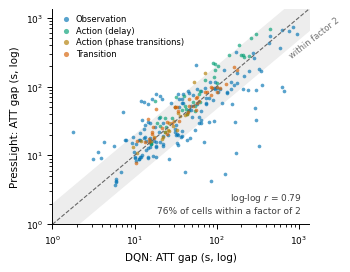

saved Figures/fig4_controllers_reward.pdf  (3.32 x 3.39 in at 1.0x)


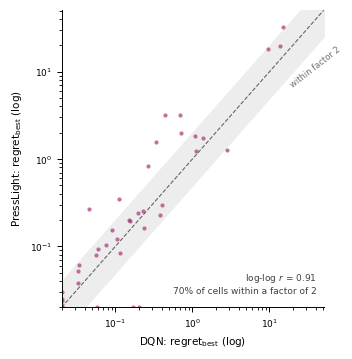

In [5]:
# Fig 4 - controller agreement (RQ4), AFTER mitigation: DQN vs PressLight per
# (axis, network, setting) cell. SPLIT 2026-07-27: the ATT scatter is the
# main-text figure and is now SINGLE COLUMN (COL_W); the reward scatter moved to
# the appendix as its own figure. Both are post-mitigation so they ask the same
# question: (main) ATT gap under the per-cell BEST-KNOWN method (min over the
# roster); (appendix) RESIDUAL reward gap under the best budgeted method
# (R_oracle - max_method R_real per cell), the reward analogue. Bands = agreement
# within a factor of 2. Single panel each, so there are no (a)/(b) subtitles;
# the axis labels carry the units.
AGENT_LABELS = {'dqn': 'DQN', 'presslight': 'PressLight'}

bestcell = (gaps[gaps.method != 'direct_transfer']
            .groupby(['axis', 'agent', 'network', 'setting'], observed=True)['gap']
            .min().reset_index())
piv = (bestcell.pivot_table(index=['axis', 'network', 'setting'], columns='agent',
                            values='gap', observed=True)
       .dropna()).clip(lower=1.0)

# ------------------------------------------------ main text: ATT, single column
fig, ax = plt.subplots(figsize=(COL_W, COL_W * 0.78))
for axis in GAP_AXES:
    sub = piv.loc[axis]
    ax.scatter(sub['dqn'], sub['presslight'], s=7, alpha=0.65,
               color=AXIS_COLORS[axis], linewidths=0, label=AXIS_LABELS[axis])
lims = [1.0, max(piv.max()) * 1.4]
xs = np.array(lims)
ax.fill_between(xs, xs / 2, xs * 2, color='0.93', zorder=0)
ax.text(lims[1] * 0.55, lims[1] * 0.20, 'within factor 2', fontsize=6, color='0.45',
        rotation=38)
ax.plot(lims, lims, color='0.4', linewidth=0.8, linestyle='--', zorder=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(f'{AGENT_LABELS["dqn"]}: ATT gap (s, log)', fontsize=7.5)
ax.set_ylabel(f'{AGENT_LABELS["presslight"]}: ATT gap (s, log)', fontsize=7.5)
ax.tick_params(labelsize=6.5)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=6, frameon=False, loc='upper left', handletextpad=0.2,
          borderaxespad=0.2, labelspacing=0.3, markerscale=1.4)
piv2 = piv.assign(dis=np.abs(np.log10(piv['dqn'] / piv['presslight'])))
corr = np.corrcoef(np.log10(piv['dqn']), np.log10(piv['presslight']))[0, 1]
within2 = (piv2['dis'] < np.log10(2)).mean()
ax.text(0.97, 0.04, f'log-log $r$ = {corr:.2f}\n{within2:.0%} of cells within a factor of 2',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=6.5, color='0.25',
        linespacing=1.3)
fig.set_layout_engine('tight')  # persistent: save() resizes and re-draws
save(fig, 'fig4_controllers', target_w=COL_W)
plt.show()

# ------------------------------------------------- appendix: reward, single column
# residual R_real gap under the best budgeted method = R_oracle - max_method
# R_real per cell (label-aligned Series subtraction; both carry the
# (agent, network, setting) index). Floored at 0.02 for the log axis -- cells
# where the best method reaches the skyline pile at the corner (both controllers
# fully recover -> agree at the floor).
r_meth_best = (rewards[rewards.method != 'direct_transfer']
               .groupby(['agent', 'network', 'setting'])['R_real'].max())
rshort = (r_oracle - r_meth_best).reset_index(name='short')
rpiv = (rshort.pivot_table(index=['network', 'setting'], columns='agent',
                           values='short')
        .dropna()).clip(lower=0.02)
figr, axr = plt.subplots(figsize=(COL_W, COL_W * 1.02))
axr.scatter(rpiv['dqn'], rpiv['presslight'], s=9, alpha=0.7,
            color=AXIS_COLORS['reward'], linewidths=0)
rlims = [0.02, max(rpiv.max().max(), 1.0) * 1.6]
rxs = np.array(rlims)
axr.fill_between(rxs, rxs / 2, rxs * 2, color='0.93', zorder=0)
axr.text(rlims[1] * 0.35, rlims[1] * 0.13, 'within factor 2', fontsize=6,
         color='0.45', rotation=38)
axr.plot(rlims, rlims, color='0.4', linewidth=0.8, linestyle='--', zorder=1)
axr.set_xscale('log'); axr.set_yscale('log')
axr.set_xlim(rlims); axr.set_ylim(rlims)
axr.set_xlabel(rf'{AGENT_LABELS["dqn"]}: $\mathrm{{regret}}_{{\mathrm{{best}}}}$ (log)',
               fontsize=7.5)
axr.set_ylabel(rf'{AGENT_LABELS["presslight"]}: $\mathrm{{regret}}_{{\mathrm{{best}}}}$ (log)',
               fontsize=7.5)
axr.tick_params(labelsize=6.5)
axr.spines[['top', 'right']].set_visible(False)
rw2 = np.abs(np.log10(rpiv['dqn'] / rpiv['presslight']))
rcorr = np.corrcoef(np.log10(rpiv['dqn']), np.log10(rpiv['presslight']))[0, 1]
rwithin = (rw2 < np.log10(2)).mean()
axr.text(0.97, 0.04, f'log-log $r$ = {rcorr:.2f}\n{rwithin:.0%} of cells within a factor of 2',
         transform=axr.transAxes, ha='right', va='bottom', fontsize=6.5, color='0.25',
         linespacing=1.3)
figr.set_layout_engine('tight')
save(figr, 'fig4_controllers_reward', target_w=COL_W)
plt.show()
